In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=sns.load_dataset("titanic")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df=df.drop(["deck"],axis=1)

In [5]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,classification_report,accuracy_score


In [7]:
y=df["survived"]
x=df.drop(columns=["survived"],axis=1)

In [8]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          714 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  embark_town  889 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(3), object(5)
memory usage: 72.5+ KB


In [9]:
num_cols = x.select_dtypes(include=["number","bool"]).columns
num_cols

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone'], dtype='object')

In [10]:
cat_cols = x.select_dtypes(exclude=["number","bool"]).columns
cat_cols

Index(['sex', 'embarked', 'class', 'who', 'embark_town', 'alive'], dtype='object')

In [11]:
cat_cols

Index(['sex', 'embarked', 'class', 'who', 'embark_town', 'alive'], dtype='object')

In [12]:
num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="mean")),
    ("scaling",StandardScaler())
])

In [13]:
cat_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='constant', fill_value='missing')),
    ("encoding",OneHotEncoder(drop="first", handle_unknown='ignore'))
])

In [14]:
Column_Transformer=ColumnTransformer([
    ("num_cols",num_pipeline,num_cols),
    ("cat_cols",cat_pipeline,cat_cols)
    ])

In [15]:
model=Pipeline([
    ("preprocess",Column_Transformer),
    ("model",LogisticRegression())
])

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=101)

In [17]:
model.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone'], dtype='object')),
                                                 ('cat_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['sex', 'embarked', 'class', 'who', 'embark_town', 'alive'], dtype='object'))])),
                ('model', LogisticRegression())])

In [18]:
y_pred=model.predict(x_test)

In [19]:
accuracy_score(y_test,y_pred)

1.0

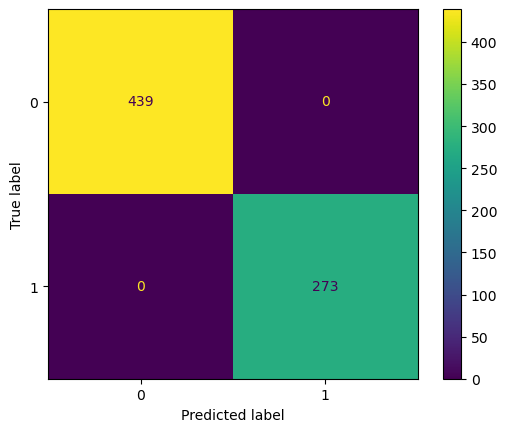

In [24]:
ConfusionMatrixDisplay.from_estimator(model,x_train,y_train)

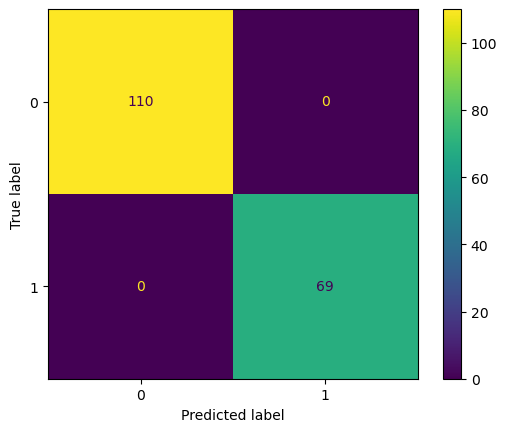

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        69

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



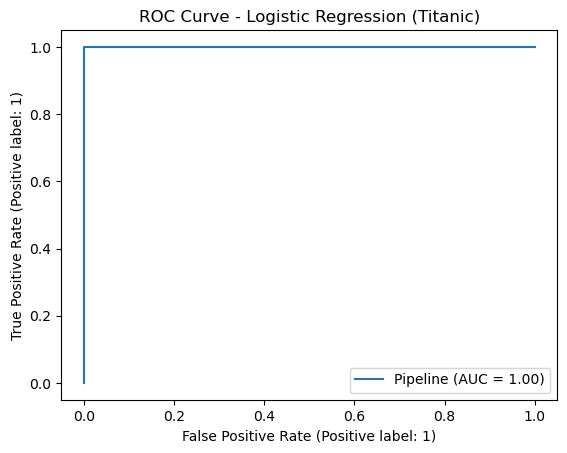

In [27]:
from sklearn.metrics import RocCurveDisplay

# This will automatically handle the preprocessing and prediction
RocCurveDisplay.from_estimator(model, x_train, y_train)
plt.title("ROC Curve - Logistic Regression (Titanic)")
plt.show()